### 1-D heat diffusion. 

##### Generic transport equation modified for temperature.

$\frac{\partial (\rho T)}{\partial t} + \mathrm{div}(\rho \mathbf{u} T) = \mathrm{div}(k \nabla T) + S_T $

For steady-state pure heat diffusion, the modified equation has no transient term and no convective term

- Steady state => $\phi$ does not change with time. 
- Pure diffusion => No bulk motion of fluid $u = 0$

$ \mathrm{div}(k \nabla T) + S_T = 0 $

##### For 1d problem where we assume that T only changes in direction of x 
$ \frac{d}{dx}\left(k \frac{dT}{dx}\right) + S_T = 0 $


In [106]:
import sympy 
from sympy import Symbol 

# coefficients 
def a_w(k, A, del_x):
    return k * A / del_x 

def a_e(k, A, del_x):
    return k * A / del_x

def a_p(a_w, a_e, s_p):
    return a_w + a_e - s_p

def s_p_(k, A, del_x):
    return -2*k * A / del_x

def s_a_(k, A, del_x, T):
    return 2*k * (A / del_x) * T

no_discretization_sections = 5
L = 0.5  # length of the domain in m
T_start = 100
T_end = 500
A_value = 10*10**-3  # cross-sectional area in m^2
del_x_value = L/no_discretization_sections  # distance between nodes in m
k_value = 1000  # thermal conductivity in W/mK

x_values =  [0,del_x_value/2] + [del_x_value for i in range(0, no_discretization_sections-1)] + [del_x_value/2]

for i in range(1, len(x_values)):
    x_values[i] = x_values[i-1] + x_values[i]

# defining the nodes and boundary conditions for the finite no source scenario
nodes = [Symbol('T'+str(i)) for i in range(no_discretization_sections)]
boundary_conditions = [nodes[0], nodes[-1]]

# defining the coefficients for each node
k = Symbol('k')  # thermal conductivity
A = Symbol('A')  # cross-sectional area
del_x = Symbol('del_x')  # distance between nodes
s_p = Symbol('s_p')  # source term, which is zero for no source scenario
equations = []

# for nodes 1 to 4, we calculate the coefficients
for i in range(1, len(nodes)-1):
    a_w_i = a_w(k, A, del_x)
    a_e_i = a_e(k, A, del_x)
    a_p_i = a_p(a_w_i, a_e_i, s_p)
       
     # Represents the discretized equation for node i
    discretized_equation = a_w_i*nodes[i-1] + a_e_i*nodes[i+1] - a_p_i*nodes[i] 
    discretized_equation = discretized_equation.subs({s_p: 0, k: k_value, A: A_value, del_x: del_x_value})
    equations.append(discretized_equation)

# discretised equation for node 0
s_p_0 = s_p_(k, A, del_x)
a_e_0 = a_e(k, A, del_x)
a_w_0 = 0 
a_p_0 = a_p(a_w_0, a_e_0, s_p_0)
s_u_0 = s_a_(k, A, del_x, T_start)
discretized_equation_0 = a_w_0*nodes[0] + a_e_0*nodes[1] - a_p_0*nodes[0] +s_u_0
discretized_equation_0 = discretized_equation_0.subs({k: k_value, A: A_value, del_x: del_x_value})
equations.append(discretized_equation_0)

# discretised equation for last node 
s_p_end = s_p_(k, A, del_x)
a_e_end = 0
a_w_end = a_w(k, A, del_x) 
a_p_end = a_p(a_w_end, a_e_end, s_p_end)
s_u_end = s_a_(k, A, del_x, T_end)
discretized_equation_end = a_w_end*nodes[-2] + a_e_end*nodes[-1] - a_p_end*nodes[-1] +s_u_end
discretized_equation_end = discretized_equation_end.subs({k: k_value, A: A_value, del_x: del_x_value})
equations.append(discretized_equation_end)

for i in range(len(equations)):
    print(f"Equation for node {i}: {equations[i]}")

# solve equations 
solution = sympy.solve(equations, nodes)
# add T_start and T_end to the solution array of values
solution_list = [T_start] + list(solution.values()) + [T_end]
solution_list

Equation for node 0: 100.0*T0 - 200.0*T1 + 100.0*T2
Equation for node 1: 100.0*T1 - 200.0*T2 + 100.0*T3
Equation for node 2: 100.0*T2 - 200.0*T3 + 100.0*T4
Equation for node 3: -300.0*T0 + 100.0*T1 + 20000.0
Equation for node 4: 100.0*T3 - 300.0*T4 + 100000.0


[100,
 140.000000000000,
 220.000000000000,
 300.000000000000,
 380.000000000000,
 460.000000000000,
 500]

[0.   0.05 0.15 0.25 0.35 0.45 0.5 ]


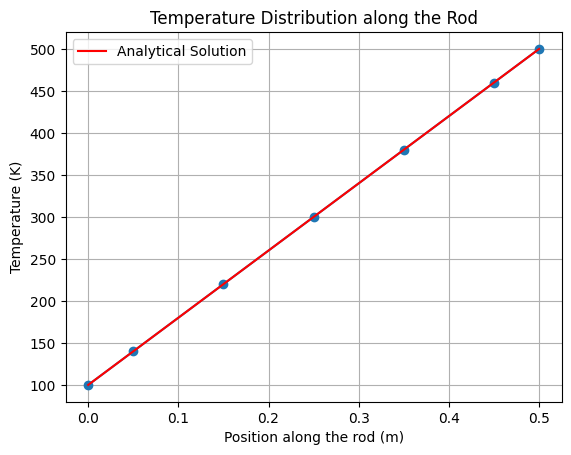

In [ ]:
# plot the results with 0 to L on the x-axis and temperature on the y-axis
import matplotlib.pyplot as plt
import numpy as np
x_values = np.array(x_values)
y_values = solution_list
plt.plot(x_values, y_values, marker='o')
plt.title('Temperature Distribution along the Rod')
plt.xlabel('Position along the rod (m)')
plt.ylabel('Temperature (K)')
plt.grid()
print (x_values)

# plot numercal solution as points with T = 800x+100
y_values_analytical = 800*x_values + 100
plt.plot(x_values, y_values_analytical, label='Analytical Solution', color='red')
plt.legend()    

plt.show()
